In [1]:
from pathlib import Path
import shutil

archive_dir = Path(r"C:\Users\clawr\OneDrive\Desktop\archive")
dest_dir = Path(r"C:\Data\wildfires")
dest_dir.mkdir(parents=True, exist_ok=True)

# Find all .sqlite files (also try common alternates)
candidates = list(archive_dir.rglob("*.sqlite")) + \
             list(archive_dir.rglob("*.db")) + \
             list(archive_dir.rglob("*.sqlite3"))

print("Found candidates:")
for p in candidates:
    try:
        print(f"- {p} | {p.stat().st_size:,} bytes")
    except FileNotFoundError:
        pass

assert candidates, "No .sqlite/.db files found. If you only see a ZIP/7z, extract it first."

# Pick the largest file (should be ~ hundreds of MB)
src = max(candidates, key=lambda p: p.stat().st_size)
print("\nUsing:", src, "| size:", f"{src.stat().st_size:,}", "bytes")

dst = dest_dir / src.name
shutil.copy2(src, dst)
print("Copied to:", dst, "| size:", f"{dst.stat().st_size:,}", "bytes")


Found candidates:
- C:\Users\clawr\OneDrive\Desktop\archive\FPA_FOD_20170508.sqlite | 795,785,216 bytes

Using: C:\Users\clawr\OneDrive\Desktop\archive\FPA_FOD_20170508.sqlite | size: 795,785,216 bytes
Copied to: C:\Data\wildfires\FPA_FOD_20170508.sqlite | size: 795,785,216 bytes


In [2]:
with open(dst, "rb") as f:
    sig = f.read(16)
print("Header:", sig)
assert sig.startswith(b"SQLite format 3"), "Not a valid SQLite DB — re-extract the .sqlite or check the source file."


Header: b'SQLite format 3\x00'


In [3]:
import sqlite3, pandas as pd

conn = sqlite3.connect(f"file:{dst.as_posix()}?mode=ro", uri=True)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
tables


,name
0,ElementaryGeometries
1,Fires
2,KNN
3,NWCG_UnitIDActive_20170109
4,SpatialIndex
5,geometry_columns
6,geometry_columns_auth
7,geometry_columns_field_infos
8,geometry_columns_statistics
9,geometry_columns_time


In [4]:
# Try common names first; fall back to largest table
common_names = ["Fires", "FPA_FOD", "fire_occurrence", "fires"]

main_table = None
for t in common_names:
    try:
        n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t};", conn).iloc[0,0]
        main_table = t
        break
    except Exception:
        pass

if main_table is None:
    counts = []
    for t in tables["name"]:
        try:
            n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t};", conn).iloc[0,0]
            counts.append((t, n))
        except Exception:
            pass
    counts.sort(key=lambda x: x[1], reverse=True)
    assert counts, "No readable tables found."
    main_table = counts[0][0]

print("Main table detected:", main_table)


Main table detected: Fires


In [5]:
nm = pd.read_sql(f"SELECT * FROM {main_table} WHERE STATE='NM';", conn)
print("NM shape:", nm.shape)
nm.head()


NM shape: (37478, 39)


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,20,20,FS-1418887,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,0308,Lincoln National Forest,...,A,33.440833,-105.720556,5.0,USFS,NM,27,027,Lincoln,b'\x00\x01\xad\x10\x00\x00\xa8I\x11\x95\x1dnZ\...
1,21,21,FS-1418888,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,0308,Lincoln National Forest,...,A,33.307222,-105.628611,13.0,STATE OR PRIVATE,NM,27,027,Lincoln,b'\x00\x01\xad\x10\x00\x00\x88\xd6\x17*;hZ\xc0...
2,22,22,FS-1418893,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,0308,Lincoln National Forest,...,A,33.444444,-105.768056,5.0,USFS,NM,27,027,Lincoln,"b""\x00\x01\xad\x10\x00\x00|\xed\x81\xd2'qZ\xc0..."
3,23,23,FS-1418894,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,0308,Lincoln National Forest,...,A,33.559444,-105.766111,5.0,USFS,NM,27,027,Lincoln,b'\x00\x01\xad\x10\x00\x00T\xa3\xe4\xf6\x07qZ\...
4,24,24,FS-1418895,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,0308,Lincoln National Forest,...,A,33.308056,-105.526111,5.0,USFS,NM,27,027,Lincoln,b'\x00\x01\xad\x10\x00\x00\xc8\xe0\xee\xcd\xab...


In [6]:
out_csv = dest_dir / "NM_Wildfires.csv"
nm.to_csv(out_csv, index=False)
print("Saved:", out_csv)


Saved: C:\Data\wildfires\NM_Wildfires.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OBJECTID,37478.0,NaN,NaN,NaN,577920.382624,539963.705872,20.0,160901.25,338653.5,723930.75,1860050.0
FOD_ID,37478.0,NaN,NaN,NaN,34938275.292065,83726915.99366,20.0,162472.25,347155.5,821992.75,300293902.0
FPA_ID,37478,37477,FS-1452833,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_SYSTEM_TYPE,37478,3,FED,25628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_SYSTEM,37478,6,DOI-WFMI,12742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NWCG_REPORTING_AGENCY,37478,7,FS,12696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NWCG_REPORTING_UNIT_ID,37478,54,USNMNMS,11144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NWCG_REPORTING_UNIT_NAME,37478,54,New Mexico - State Forestry,11144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_REPORTING_UNIT,37478,307,NMNMS,8887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_REPORTING_UNIT_NAME,37478,66,New Mexico - State Forestry,11144,NaN,NaN,NaN,NaN,NaN,NaN,NaN


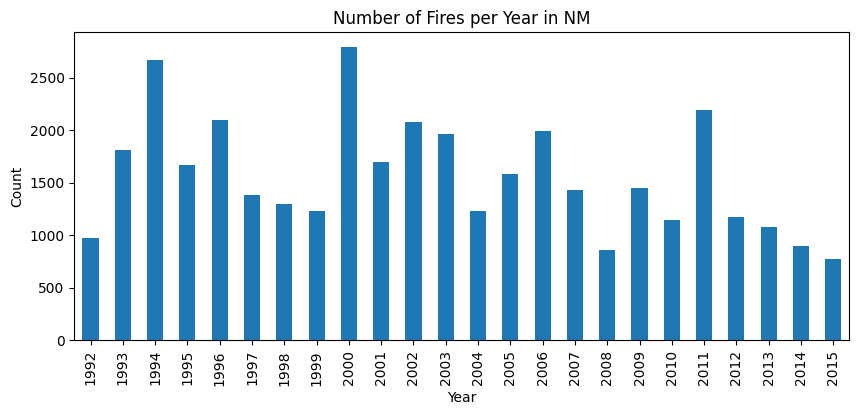

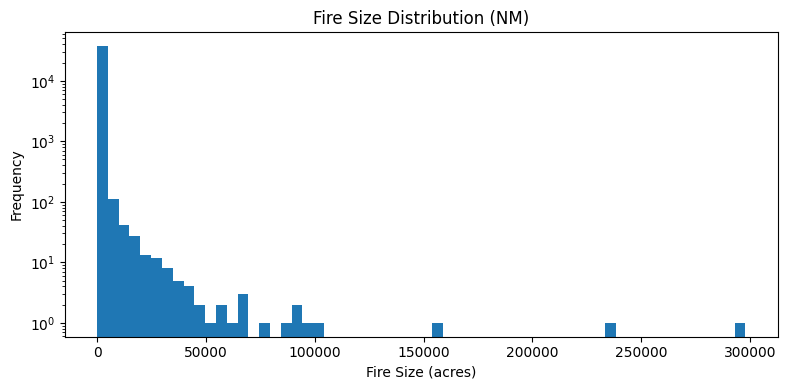

STAT_CAUSE_DESCR
Lightning            18006
Missing/Undefined     5140
Debris Burning        3937
Miscellaneous         3620
Campfire              1923
Arson                 1426
Equipment Use         1419
Smoking                815
Children               462
Powerline              308
Name: count, dtype: int64

In [7]:
# (Optional) quick checks for your Phase 3 PDF
display(nm.describe(include='all').T.head(25))

if "FIRE_YEAR" in nm.columns:
    ax = nm["FIRE_YEAR"].value_counts().sort_index().plot(kind="bar", figsize=(10,4))
    ax.set_title("Number of Fires per Year in NM"); ax.set_xlabel("Year"); ax.set_ylabel("Count")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
nm["FIRE_SIZE"].dropna().plot(kind="hist", bins=60, logy=True)
plt.title("Fire Size Distribution (NM)"); plt.xlabel("Fire Size (acres)"); plt.tight_layout(); plt.show()

for c in ["STAT_CAUSE_DESCR","CAUSE","CAUSE_DESC"]:
    if c in nm.columns:
        display(nm[c].value_counts().head(10))
        break


In [8]:
import sqlite3, pandas as pd, os
db = r"C:\Data\wildfires\FPA_FOD_20170508.sqlite"
assert os.path.exists(db), f"DB not found at: {db}"
conn = sqlite3.connect(f"file:{db}?mode=ro", uri=True)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
tables


,name
0,ElementaryGeometries
1,Fires
2,KNN
3,NWCG_UnitIDActive_20170109
4,SpatialIndex
5,geometry_columns
6,geometry_columns_auth
7,geometry_columns_field_infos
8,geometry_columns_statistics
9,geometry_columns_time


In [9]:
# choose main table
names = tables["name"].tolist()
table = "Fires" if "Fires" in names else ("FPA_FOD" if "FPA_FOD" in names else names[0])

# export NM rows
out = r"C:\Data\wildfires\NM_Wildfires.csv"
sql = f"SELECT * FROM {table} WHERE STATE='NM';"

first = True
for chunk in pd.read_sql_query(sql, conn, chunksize=100_000):
    chunk.to_csv(out, index=False, header=first, mode="w" if first else "a")
    first = False

print("Saved:", out)


Saved: C:\Data\wildfires\NM_Wildfires.csv


In [10]:
nm = pd.read_csv(out, nrows=5)
nm


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,20,20,FS-1418887,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,308,Lincoln National Forest,...,A,33.440833,-105.720556,5.0,USFS,NM,27,27,Lincoln,b'\x00\x01\xad\x10\x00\x00\xa8I\x11\x95\x1dnZ\...
1,21,21,FS-1418888,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,308,Lincoln National Forest,...,A,33.307222,-105.628611,13.0,STATE OR PRIVATE,NM,27,27,Lincoln,b'\x00\x01\xad\x10\x00\x00\x88\xd6\x17*;hZ\xc0...
2,22,22,FS-1418893,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,308,Lincoln National Forest,...,A,33.444444,-105.768056,5.0,USFS,NM,27,27,Lincoln,"b""\x00\x01\xad\x10\x00\x00|\xed\x81\xd2'qZ\xc0..."
3,23,23,FS-1418894,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,308,Lincoln National Forest,...,A,33.559444,-105.766111,5.0,USFS,NM,27,27,Lincoln,b'\x00\x01\xad\x10\x00\x00T\xa3\xe4\xf6\x07qZ\...
4,24,24,FS-1418895,FED,FS-FIRESTAT,FS,USNMLNF,Lincoln National Forest,308,Lincoln National Forest,...,A,33.308056,-105.526111,5.0,USFS,NM,27,27,Lincoln,b'\x00\x01\xad\x10\x00\x00\xc8\xe0\xee\xcd\xab...


(37478, 39)
['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT', 'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID', 'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME', 'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'Shape']
COMPLEX_NAME               37352
MTBS_ID                    36912
MTBS_FIRE_NAME             36912
ICS_209_INCIDENT_NUMBER    36661
ICS_209_NAME               36661
LOCAL_INCIDENT_ID          21745
FIRE_CODE                  21340
COUNTY                     21090
FIPS_CODE                  21090
FIPS_NAME                  21090
LOCAL_FIRE

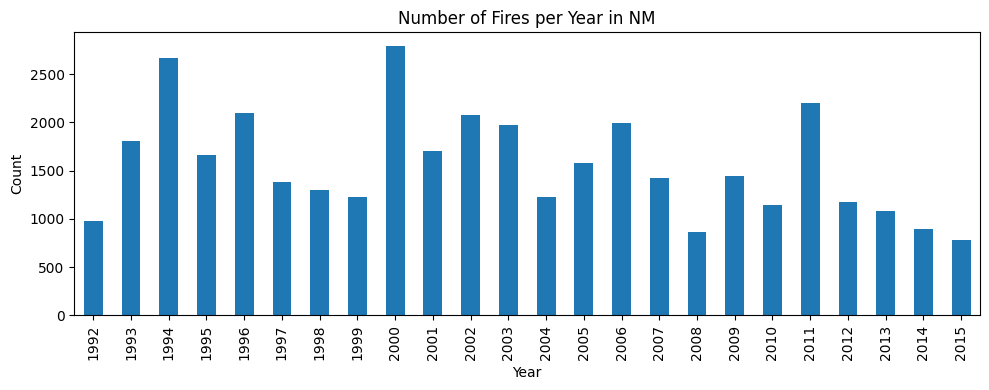

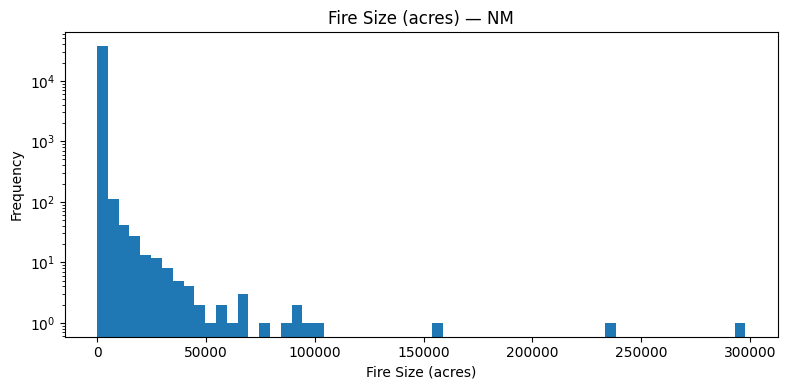

STAT_CAUSE_DESCR
Lightning            18006
Missing/Undefined     5140
Debris Burning        3937
Miscellaneous         3620
Campfire              1923
Arson                 1426
Equipment Use         1419
Smoking                815
Children               462
Powerline              308
Name: count, dtype: int64


In [13]:
import pandas as pd, matplotlib.pyplot as plt

csv_path = r"C:\Data\wildfires\NM_Wildfires.csv"
nm = pd.read_csv(csv_path)

# Column overview
print(nm.shape)
print(nm.columns.tolist())
print(nm.isnull().sum().sort_values(ascending=False).head(15))

# Fires per year
if "FIRE_YEAR" in nm.columns:
    ax = nm["FIRE_YEAR"].value_counts().sort_index().plot(kind="bar", figsize=(10,4))
    ax.set_title("Number of Fires per Year in NM")
    ax.set_xlabel("Year"); ax.set_ylabel("Count")
    plt.tight_layout(); plt.show()

# Fire size distribution
nm["FIRE_SIZE"].dropna().plot(kind="hist", bins=60, logy=True, figsize=(8,4), title="Fire Size (acres) — NM")
plt.xlabel("Fire Size (acres)"); plt.tight_layout(); plt.show()

# Top causes (try common column names)
for c in ["STAT_CAUSE_DESCR","CAUSE","CAUSE_DESC"]:
    if c in nm.columns:
        print(nm[c].value_counts().head(10))
        break
